# OSHA Construction Incident EDA

Exploratory analysis of `data/processed/osha_clean.csv` (4,470 cleaned OSHA construction accident records).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/osha_clean.csv")
df.shape

(4470, 19)

## 1. Overview

In [2]:
print(f"Shape: {df.shape}")
df.dtypes

Shape: (4470, 19)


id                      int64
title                     str
narrative                 str
narrative_length        int64
industry                int64
industry_name             str
occupation                str
occupation_primary        str
injury_type               str
cause                     str
cause_clean               str
fatality_cause            str
is_fatality              bool
is_fall_incident         bool
fall_distance_ft      float64
incident_date             str
year                  float64
month                 float64
month_name                str
dtype: object

In [3]:
null_counts = df.isna().sum()
null_pct = (null_counts / len(df) * 100).round(1)
pd.DataFrame({"nulls": null_counts, "pct": null_pct}).sort_values("nulls", ascending=False)

,nulls,pct
fall_distance_ft,3111,69.6
cause_clean,2207,49.4
month,943,21.1
incident_date,943,21.1
month_name,943,21.1
year,943,21.1
fatality_cause,933,20.9
occupation_primary,7,0.2
narrative,0,0.0
id,0,0.0


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4470.0,NaN,NaN,NaN,185990636.899553,52571738.444342,511725.0,200536003.0,201161146.5,202367065.75,362661902.0
title,4470,3906,Electric Shock,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
narrative,4470,4470,On August 27 2013 Employees #1 and #2 of T...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
narrative_length,4470.0,NaN,NaN,NaN,717.607383,490.775249,81.0,389.0,554.5,913.75,4002.0
industry,4470.0,NaN,NaN,NaN,1699.831991,90.083434,1521.0,1623.0,1731.0,1771.0,1799.0
industry_name,4470,26,"Special Trade Contractors, Not Elsewhere Class...",408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,4470,255,Occupation not reported,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_primary,4463,120,Occupation not reported,1577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
injury_type,4470,23,Fracture,1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cause,4470,41,[],2145,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4,470 records, 18 columns. `fatality_cause` and the date fields (`incident_date`, `year`, `month`, `month_name`) are the only columns with real nulls — 933 non-fatal incidents have no fatality cause, and 943 records (21%) had no date extractable from the narrative. `fall_distance_ft` is null wherever `is_fall_incident` is False, by design.

## 2. Incidents by Industry

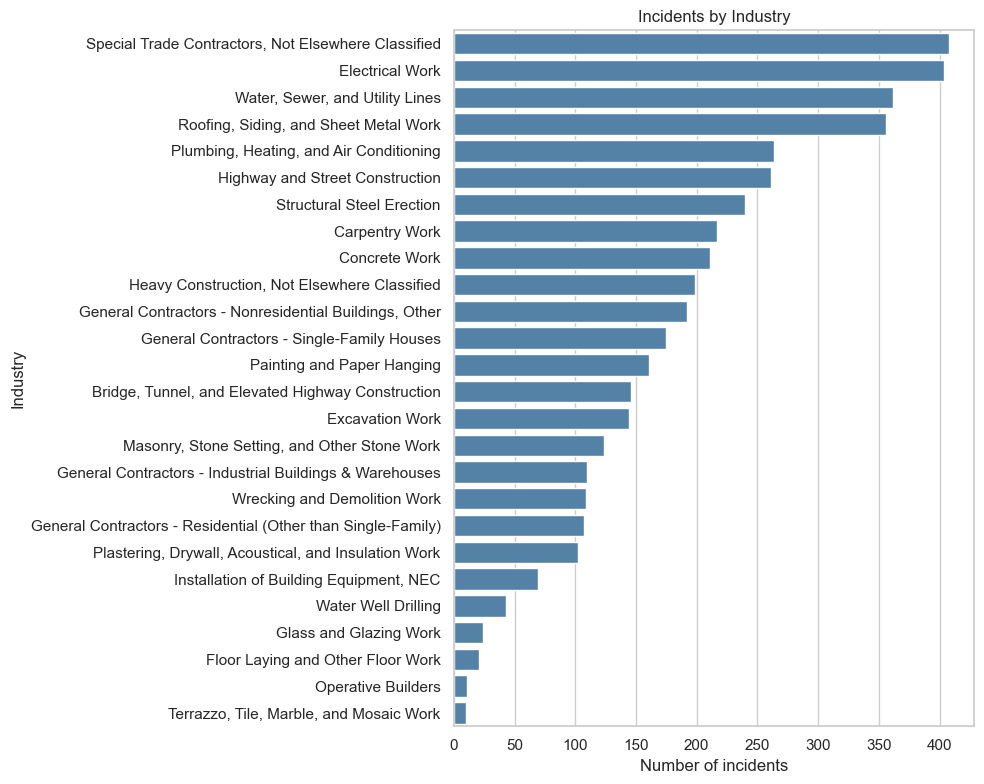

In [5]:
industry_counts = df["industry_name"].value_counts()

plt.figure(figsize=(10, 8))
sns.barplot(y=industry_counts.index, x=industry_counts.values, color="steelblue")
plt.xlabel("Number of incidents")
plt.ylabel("Industry")
plt.title("Incidents by Industry")
plt.tight_layout()
plt.show()

Incident volume is dominated by a handful of construction-related SIC industries (roofing, framing, masonry-type trades), with a long tail of lower-frequency industries.

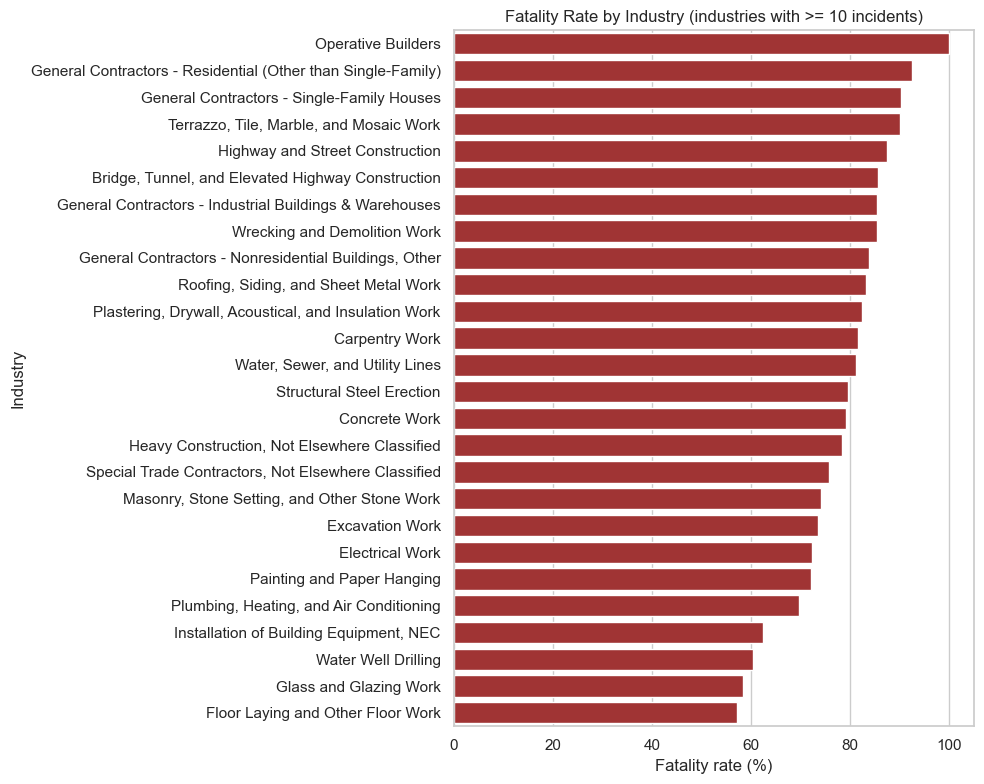

In [6]:
industry_fatality = (
    df.groupby("industry_name")["is_fatality"]
    .agg(fatality_rate="mean", n="count")
    .query("n >= 10")
    .sort_values("fatality_rate", ascending=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(y=industry_fatality.index, x=industry_fatality["fatality_rate"] * 100, color="firebrick")
plt.xlabel("Fatality rate (%)")
plt.ylabel("Industry")
plt.title("Fatality Rate by Industry (industries with >= 10 incidents)")
plt.tight_layout()
plt.show()

Restricting to industries with at least 10 recorded incidents avoids letting a single incident in a rare industry show up as a 100% fatality rate. The highest-volume industries are not necessarily the highest-risk ones — this is the first sign that "most incidents" and "most dangerous" are different questions, which comes up again with occupations below.

## 3. Incidents by Occupation

High-volume occupations (most incidents happen here) and high-risk occupations (highest fatality rate) are different questions — a common trap is treating them as the same thing.

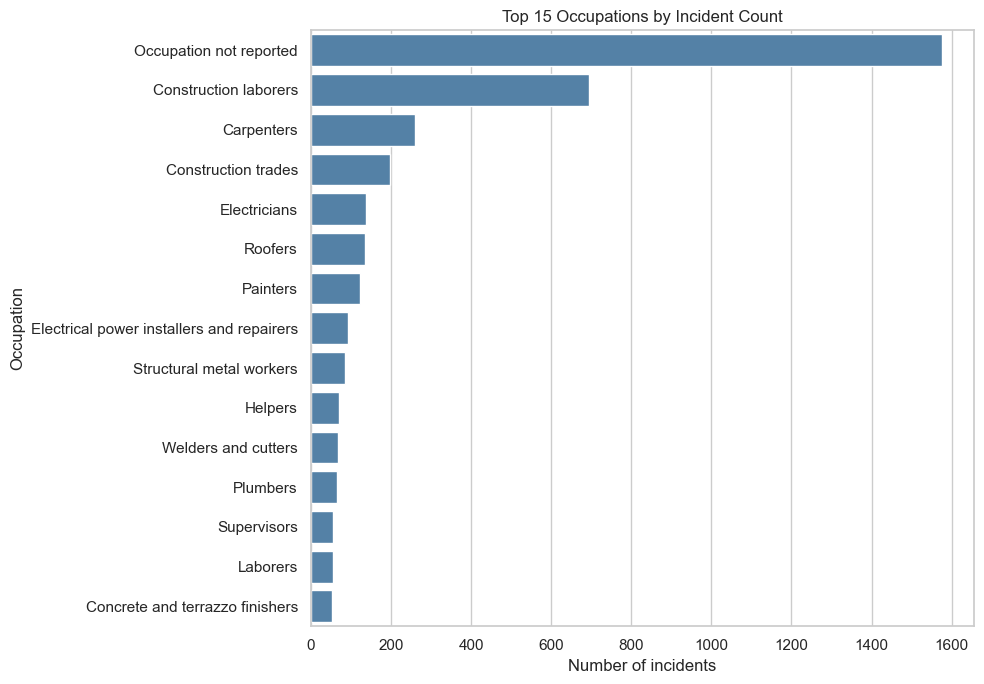

In [7]:
top_occ_count = df["occupation_primary"].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(y=top_occ_count.index, x=top_occ_count.values, color="steelblue")
plt.xlabel("Number of incidents")
plt.ylabel("Occupation")
plt.title("Top 15 Occupations by Incident Count")
plt.tight_layout()
plt.show()

"Occupation not reported" is the single largest bucket, followed by construction laborers and carpenters — high-volume, generalist trades that simply have more people exposed to risk.

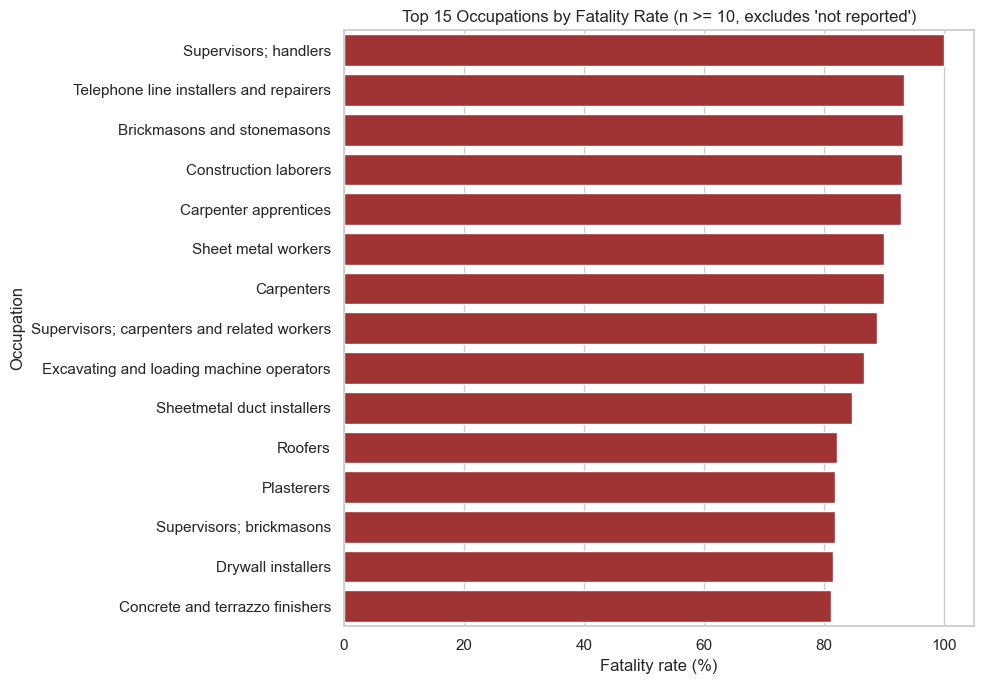

In [8]:
occ_fatality = (
    df[df["occupation_primary"] != "Occupation not reported"]
    .groupby("occupation_primary")["is_fatality"]
    .agg(fatality_rate="mean", n="count")
    .query("n >= 10")
    .sort_values("fatality_rate", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(y=occ_fatality.index, x=occ_fatality["fatality_rate"] * 100, color="firebrick")
plt.xlabel("Fatality rate (%)")
plt.ylabel("Occupation")
plt.title("Top 15 Occupations by Fatality Rate (n >= 10, excludes 'not reported')")
plt.tight_layout()
plt.show()

The occupations with the highest fatality rates are largely different from the highest-volume list above — this is the high-volume vs. high-risk split. `n >= 10` filters out occupations where one or two incidents would otherwise produce a misleadingly extreme rate.

## 4. Incidents by Injury Type and Cause

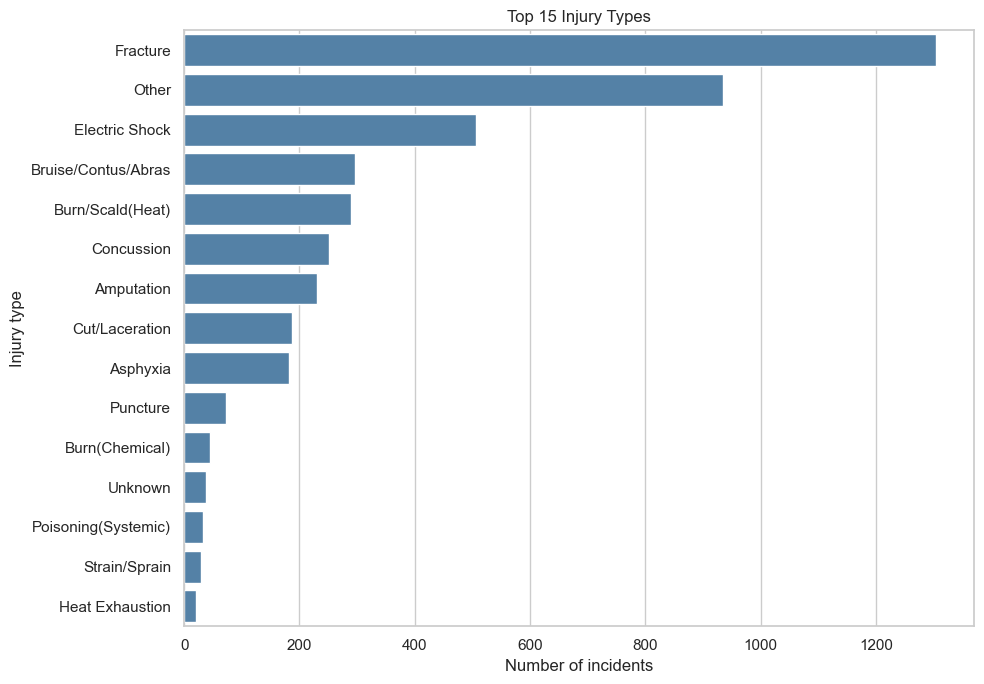

In [9]:
injury_counts = df["injury_type"].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(y=injury_counts.index, x=injury_counts.values, color="steelblue")
plt.xlabel("Number of incidents")
plt.ylabel("Injury type")
plt.title("Top 15 Injury Types")
plt.tight_layout()
plt.show()

`injury_type` is clean — only 38 of 4,470 rows (0.9%) fall back to "Unknown", so this field is reliable enough to analyze directly.

'cause' is the placeholder '[]' for 2145 of 4470 rows (48.0%)


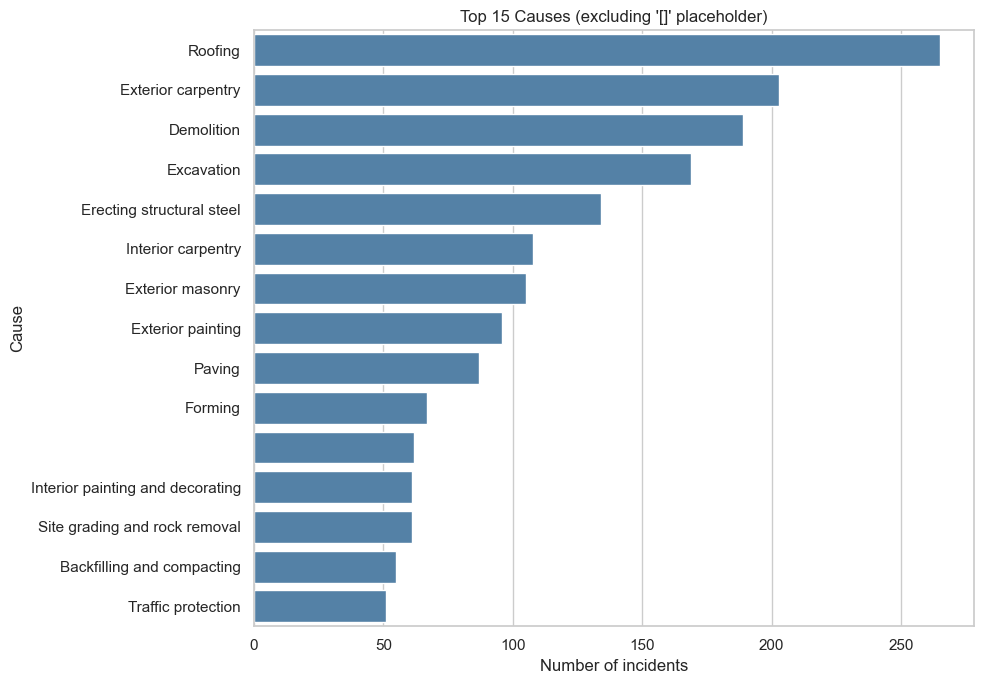

In [10]:
placeholder_count = (df["cause"] == "[]").sum()
print(f"'cause' is the placeholder '[]' for {placeholder_count} of {len(df)} rows "
      f"({placeholder_count / len(df) * 100:.1f}%)")

cause_counts = df.loc[df["cause"] != "[]", "cause"].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(y=cause_counts.index, x=cause_counts.values, color="steelblue")
plt.xlabel("Number of incidents")
plt.ylabel("Cause")
plt.title("Top 15 Causes (excluding '[]' placeholder)")
plt.tight_layout()
plt.show()

Unlike `fatality_cause`, the `cause` column was never cleaned in the pipeline — 48% of rows (2,145 of 4,470) are still the literal placeholder `'[]'`. That's a large enough gap that `cause` should be treated as unreliable/sparse for any downstream analysis unless it gets the same cleaning treatment as `fatcause` did.

## 5. Time Trends

Based on `incident_date`, parsed from the narrative text. 943 records (21%) have no parseable date and are excluded from this section.

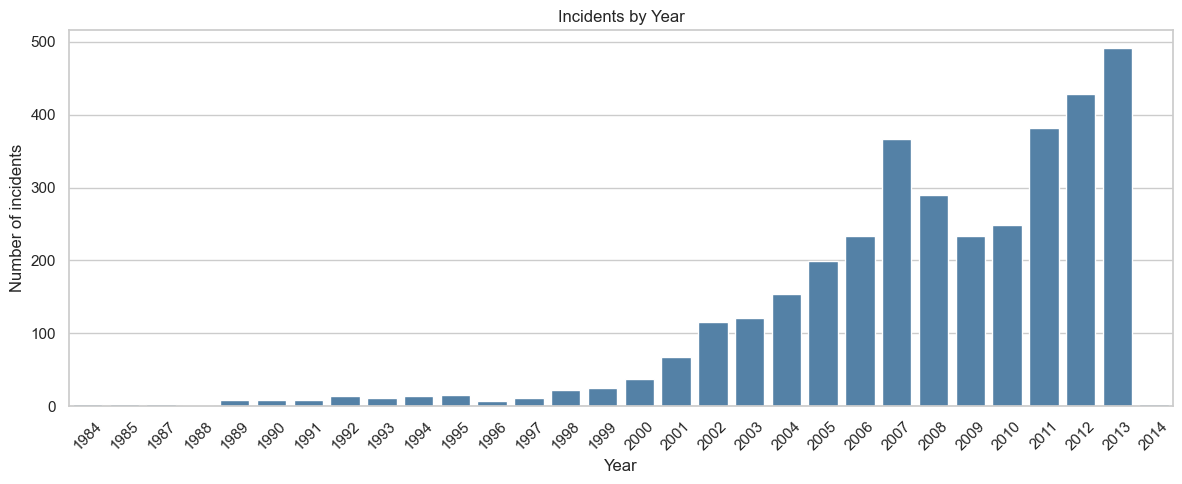

In [11]:
year_counts = df.dropna(subset=["year"]).groupby("year").size()

plt.figure(figsize=(12, 5))
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, color="steelblue")
plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.title("Incidents by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Data spans 1984–2014, but volume is uneven across years — likely reflecting which years OSHA's source site had fuller narrative coverage rather than a real change in incident rate, so year-over-year counts shouldn't be read as a trend without checking source coverage.

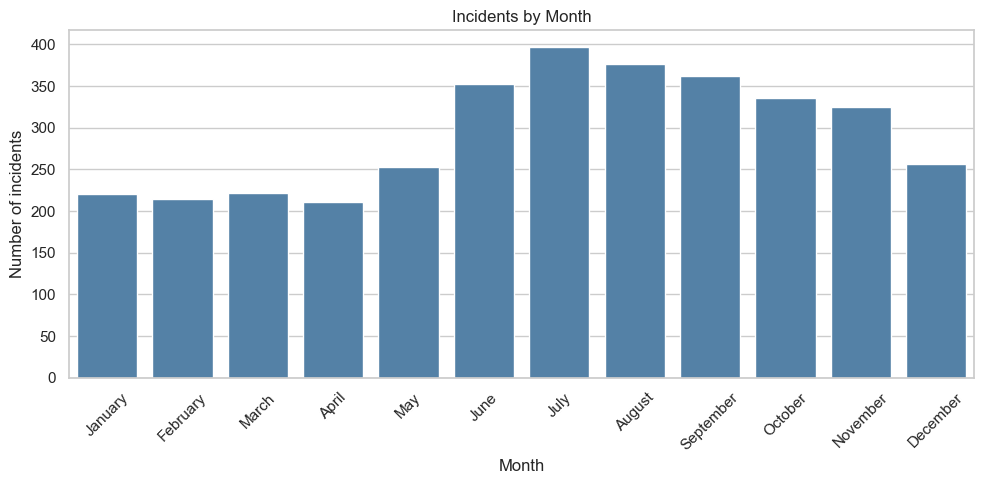

In [12]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
month_counts = df.dropna(subset=["month_name"])["month_name"].value_counts().reindex(month_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=month_counts.index, y=month_counts.values, color="steelblue")
plt.xlabel("Month")
plt.ylabel("Number of incidents")
plt.title("Incidents by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Aggregated across all years, incidents skew toward the warmer months — consistent with more outdoor construction activity (roofing, framing, excavation) in spring/summer.

## 6. Fall Incidents

Fall incidents: 1359 (30.4% of all incidents)
count    1359.000000
mean       32.807947
std       101.764792
min         1.000000
25%        10.000000
50%        16.000000
75%        26.000000
max      2000.000000
Name: fall_distance_ft, dtype: float64


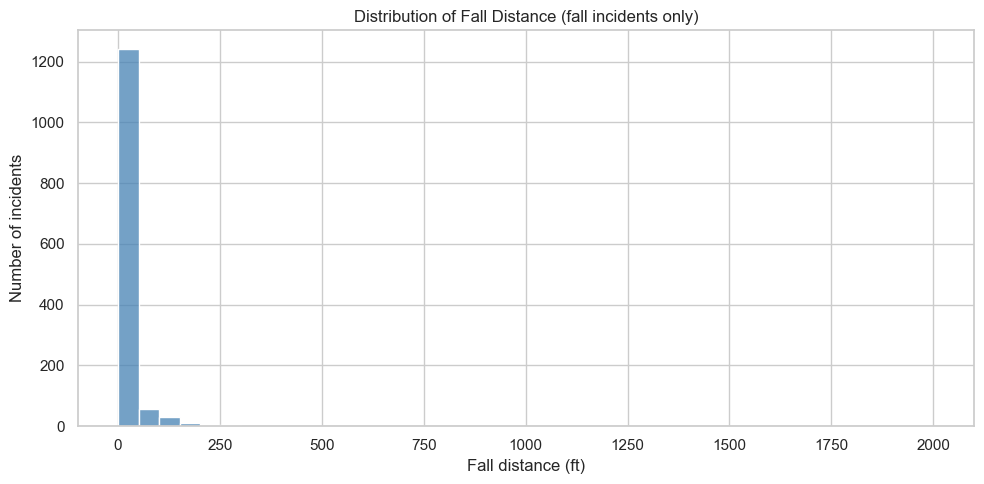

In [13]:
falls = df.loc[df["is_fall_incident"], "fall_distance_ft"]
print(f"Fall incidents: {len(falls)} ({len(falls) / len(df) * 100:.1f}% of all incidents)")
print(falls.describe())

plt.figure(figsize=(10, 5))
sns.histplot(falls, bins=40, color="steelblue")
plt.xlabel("Fall distance (ft)")
plt.ylabel("Number of incidents")
plt.title("Distribution of Fall Distance (fall incidents only)")
plt.tight_layout()
plt.show()

1,359 incidents (30% of all records) are falls. The distribution is heavily right-skewed — median fall distance is 16 ft (roughly a residential roof edge) and 75% are under 26 ft, but the max of 2,000 ft is almost certainly a data-entry or scraping error (no construction fall is 2,000 ft) and should be investigated or capped before this field is used in modeling.

## 7. Risk Heatmap: Occupation × Injury Type

Using `occupation_primary` × `injury_type` rather than `industry_name` × `cause` — `cause` is 48% placeholder `[]` values (see Section 4), which would leave the heatmap mostly empty. `injury_type` is only 0.9% "Unknown", so it has enough real data to be meaningful.

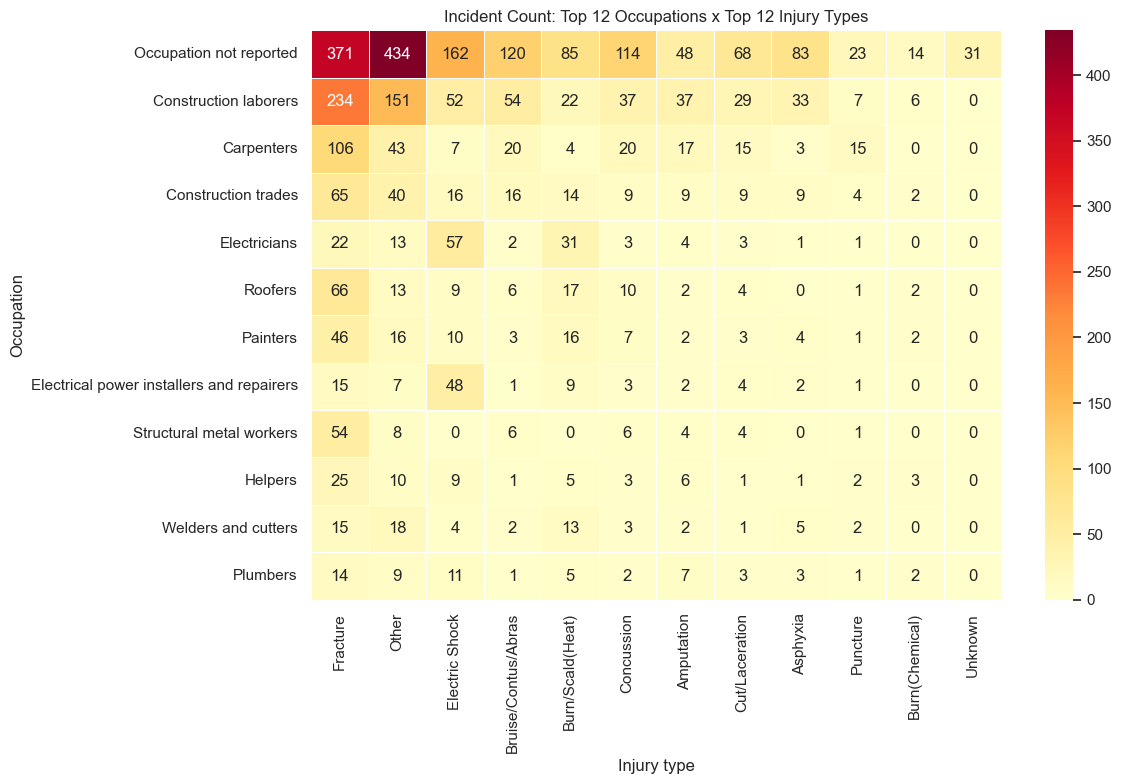

In [14]:
top_occs = df["occupation_primary"].value_counts().head(12).index
top_injuries = df["injury_type"].value_counts().head(12).index

heat_df = df[df["occupation_primary"].isin(top_occs) & df["injury_type"].isin(top_injuries)]
pivot = pd.crosstab(heat_df["occupation_primary"], heat_df["injury_type"])
pivot = pivot.loc[top_occs, top_injuries]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.xlabel("Injury type")
plt.ylabel("Occupation")
plt.title("Incident Count: Top 12 Occupations x Top 12 Injury Types")
plt.tight_layout()
plt.show()

Restricted to the top 12 occupations and top 12 injury types by volume, so the heatmap highlights the combinations with enough sample size to trust rather than sparse one-off pairings. Look for concentrated hot cells — those are the occupation/injury combinations to prioritize for targeted safety interventions.

## 8. Narrative Text Analysis

Word frequency across all narratives, then split by `is_fatality`, to see whether fatal and non-fatal incident narratives are described differently. Stopwords are removed via `CountVectorizer(stop_words="english")`.

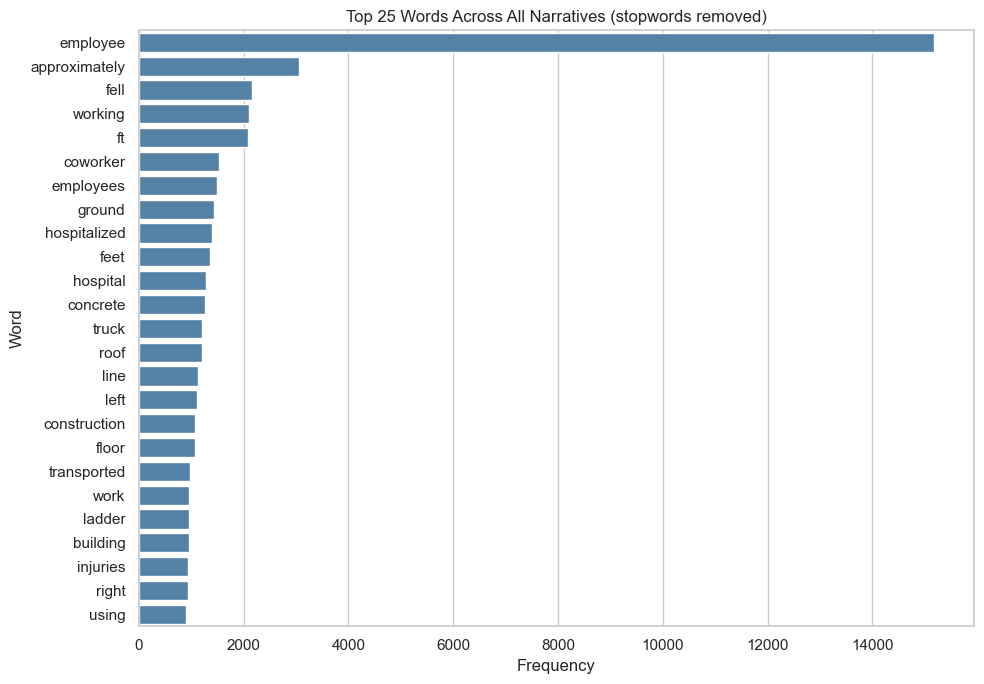

In [15]:
def top_words(texts, n=20):
    vec = CountVectorizer(stop_words="english", max_features=n)
    X = vec.fit_transform(texts.astype(str))
    freqs = np.asarray(X.sum(axis=0)).ravel()
    return pd.Series(freqs, index=vec.get_feature_names_out()).sort_values(ascending=False)

overall_top = top_words(df["narrative"], n=25)

plt.figure(figsize=(10, 7))
sns.barplot(y=overall_top.index, x=overall_top.values, color="steelblue")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 25 Words Across All Narratives (stopwords removed)")
plt.tight_layout()
plt.show()

Vocabulary is dominated by clinical/procedural incident-report language ("employee", "hospitalized", "transported") and physical-scene terms ("fell", "ft", "ground", "roof", "concrete") — consistent with these being formal OSHA narrative writeups rather than casual descriptions.

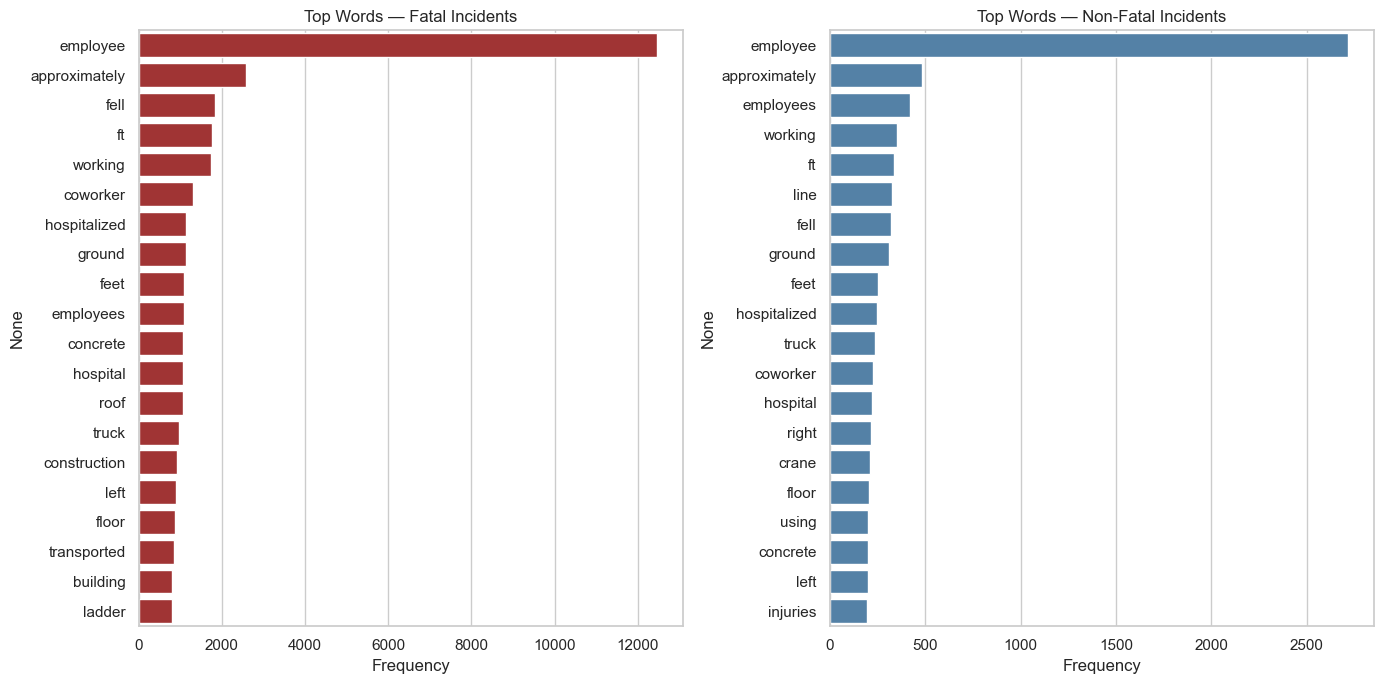

In [16]:
fatal_top = top_words(df.loc[df["is_fatality"], "narrative"], n=20)
nonfatal_top = top_words(df.loc[~df["is_fatality"], "narrative"], n=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)

sns.barplot(y=fatal_top.index, x=fatal_top.values, color="firebrick", ax=axes[0])
axes[0].set_title("Top Words — Fatal Incidents")
axes[0].set_xlabel("Frequency")

sns.barplot(y=nonfatal_top.index, x=nonfatal_top.values, color="steelblue", ax=axes[1])
axes[1].set_title("Top Words — Non-Fatal Incidents")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

Core vocabulary overlaps heavily between the two groups (both are dominated by "employee", "fell", "ground"), but fatal narratives skew toward scene/structure words ("roof", "ladder", "building", "construction") while non-fatal narratives include more equipment and outcome words ("crane", "line", "injuries"). This is a weak signal, not a strong split — word frequency alone likely won't separate fatal from non-fatal well; a smarter feature (e.g. TF-IDF or bigrams) would be needed for real text-based modeling.

## 9. Plotly Charts (for dashboard reuse)

Interactive versions of two of the charts above, built with Plotly so the same figure objects/logic can be dropped into the dashboard app later.

In [17]:
industry_summary = (
    df.groupby("industry_name")
    .agg(incidents=("id", "count"), fatality_rate=("is_fatality", "mean"))
    .query("incidents >= 10")
    .reset_index()
    .sort_values("incidents", ascending=False)
)

fig = px.bar(
    industry_summary,
    x="industry_name",
    y="incidents",
    color="fatality_rate",
    color_continuous_scale="YlOrRd",
    title="Incidents by Industry (color = fatality rate)",
    labels={"industry_name": "Industry", "incidents": "Number of incidents", "fatality_rate": "Fatality rate"},
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Combines volume and risk in one view — bar height is incident count, color is fatality rate — so high-volume, high-risk industries stand out immediately. This is the kind of combined encoding worth reusing as the dashboard's headline chart.

In [18]:
monthly_trend = (
    df.dropna(subset=["year", "month"])
    .assign(year=lambda d: d["year"].astype(int), month=lambda d: d["month"].astype(int))
    .groupby(["year", "month"])
    .size()
    .reset_index(name="incidents")
)
monthly_trend["date"] = pd.to_datetime(dict(year=monthly_trend["year"], month=monthly_trend["month"], day=1))

fig = px.line(
    monthly_trend,
    x="date",
    y="incidents",
    title="Incidents Over Time (monthly)",
    labels={"date": "Month", "incidents": "Number of incidents"},
)
fig.update_traces(mode="lines+markers")
fig.show()

Monthly resolution shows the uneven data-coverage effect from Section 5 more clearly than the yearly bar chart did — useful as a sanity-check view, and directly reusable as a time filter/trend line in the dashboard.

## Key Findings

1. **High-volume occupations are not equally risky, even among themselves.** Restricting to occupations with at least 90 recorded incidents, fatality rate still ranges from 92.9% (Construction laborers, n=693) down to 68.5% (Electrical power installers and repairers, n=92) — a 24-point spread. Incident volume alone does not predict fatality risk, even after controlling for "enough data to trust the rate."

2. **The 79.1% overall fatality rate (3,537/4,470) is a property of this dataset, not a general construction-industry statistic.** It's driven by which incidents the source site chose to scrape narratives for, not by sampling all OSHA construction cases — so it should never be quoted as "the fatality rate for construction" without that caveat, including in any model built on this data.

3. **Narrative language barely distinguishes fatal from non-fatal incidents.** The top-20 word lists for fatal vs. non-fatal narratives overlap on 15 of 20 words (both dominated by "employee", "fell", "ground", "hospitalized"). The only fatal-skewed terms are scene/structure words ("roof", "ladder", "building", "construction", "transported"), while non-fatal skews toward equipment/outcome words ("crane", "line", "injuries", "using"). Simple word-frequency features are unlikely to be a strong predictor of `is_fatality` on their own — TF-IDF, bigrams, or narrative length/structure features would likely be needed for a usable text-based model.